In [1]:
# CNN -> cifar-10 dataset
#CNN -> convolution neural network which automatically identify, visualise the image patterns without human intervention

# the image are further divided into multiple small matrix and consists of two colours: RGB (3 channels) -> range: (0,255],[255,255],[255,0) and the second is grayscale image -> 1 channel

# kernel is the function which applying on image to gather info of the matrix of the image by help of matrix multiplication that process called convolution

# But when image matrix comes 84x84 or 512 x 512 so total pixels gets higher and cant process very easily so we use dimenstionality reduction to reduce the matrix pixels by separating out the dead pixels and gets only that pixels which required to be process out.

#type of dimenstionality reduction: (all need to reduce the computing power by reducing the matrix size)
#stride
#padding
#pooling: max, average

CNN CODE

MNIST DATASET GRAYSCALE CHANNEL

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.utils import to_categorical

In [3]:
#load the dataset

(X_train, y_train),(X_test, y_test) = mnist.load_data()

print("Training Images: ")
print(X_train.shape)
print("Testing Images: ")
print(X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training Images: 
(60000, 28, 28)
Testing Images: 
(10000, 28, 28)


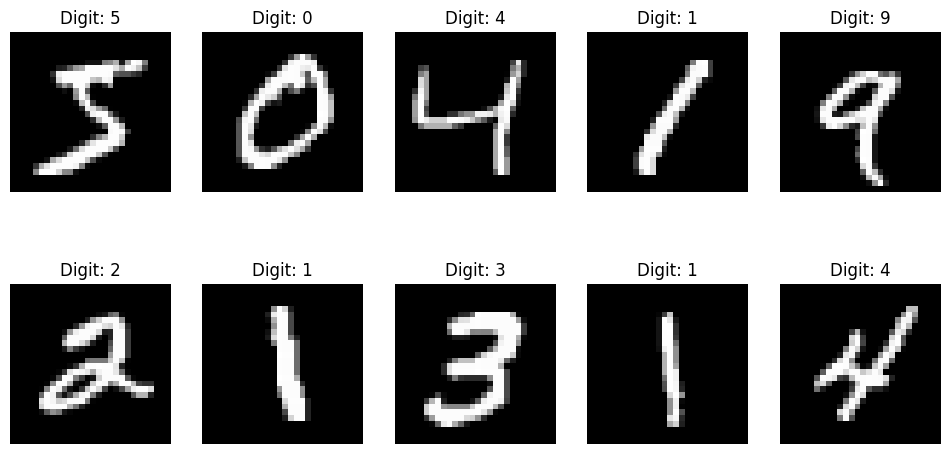

In [4]:
#visualise the figure

plt.figure(
    figsize=(12,6)
)
for i in range(10):
  plt.subplot(
      2,
      5,
      i+1
    )

  plt.imshow(
      X_train[i],
      cmap="gray"
    )

  plt.title(
      f"Digit: {y_train[i]}"
  )
  plt.axis("off")

plt.show()

In [5]:
# class distribution

class_counts =pd.Series(
    y_train
).value_counts().sort_index()

print(class_counts)

0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64


In [6]:
# normalisation

X_train = X_train / 255.0
X_test = X_test / 255.0

print(X_train.min())
print(X_train.max())

0.0
1.0


In [7]:
#reshape

X_train = X_train.reshape(
    -1,
    28,
    28,
    1
)

X_test = X_test.reshape(
    -1,
    28,
    28,
    1
)

print(X_train.shape)

(60000, 28, 28, 1)


In [8]:
# one hot encoding -> converts categorical to numerical values

y_train_cat = to_categorical(
    y_train
)
y_test_cat = to_categorical(
    y_test
)

print(
    y_train_cat[0]
)

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [9]:
# if we having any class imbalance so we use argumentation technique

In [11]:
# CNN architecture

model = Sequential()

# model convolution layer

# ------------------------------------------------------------
# CONVOLUTION LAYER 1
# ------------------------------------------------------------

model.add(

    Conv2D(

        filters=32,

        kernel_size=(3,3),

        activation="relu",

        input_shape=(28,28,1)

    )

)


# ------------------------------------------------------------
# POOLING
# ------------------------------------------------------------

model.add(

    MaxPooling2D(

        pool_size=(2,2)

    )

)

# ------------------------------------------------------------
# CONVOLUTION LAYER 2
# ------------------------------------------------------------

model.add(

    Conv2D(

        filters=64,

        kernel_size=(3,3),

        activation="relu"

    )

)

# ------------------------------------------------------------
# POOLING
# ------------------------------------------------------------

model.add(

    MaxPooling2D(

        pool_size=(2,2)

    )

)

# ------------------------------------------------------------
# FLATTEN
# ------------------------------------------------------------

model.add(
    Flatten()
)

# ------------------------------------------------------------
# DENSE LAYER
# ------------------------------------------------------------

model.add(

    Dense(

        128,

        activation="relu"

    )

)

# ------------------------------------------------------------
# DROPOUT
# ------------------------------------------------------------

model.add(
    Dropout(0.3)
)

# ------------------------------------------------------------
# OUTPUT LAYER
# ------------------------------------------------------------

model.add(

    Dense(

        10,

        activation="softmax"

    )

)

model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# ============================================================
# COMPILE MODEL
# ============================================================

model.compile(

    optimizer="adam",

    loss="categorical_crossentropy",

    metrics=["accuracy"]

)

In [13]:
# ============================================================
# TRAIN CNN
# ============================================================

history = model.fit(

    X_train,

    y_train_cat,

    validation_split=0.2,

    epochs=10,

    batch_size=64

)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 46s 59ms/step - accuracy: 0.9373 - loss: 0.2062 - val_accuracy: 0.9816 - val_loss: 0.0628
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 46s 62ms/step - accuracy: 0.9802 - loss: 0.0669 - val_accuracy: 0.9862 - val_loss: 0.0453
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 45s 60ms/step - accuracy: 0.9852 - loss: 0.0472 - val_accuracy: 0.9859 - val_loss: 0.0460
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 57ms/step - accuracy: 0.9885 - loss: 0.0375 - val_accuracy: 0.9887 - val_loss: 0.0386
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 56ms/step - accuracy: 0.9897 - loss: 0.0319 - val_accuracy: 0.9898 - val_loss: 0.0365
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 56ms/step - accuracy: 0.9919 - loss: 0.0255 - val_accuracy: 0.9903 - val_loss: 0.0360
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 58ms/step - accuracy: 0.9928 - loss: 0.0226 - val_accuracy: 0.9902 - val_loss: 0.0355
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 57ms/step - accuracy: 0.9940 - loss: 0.0179 - 

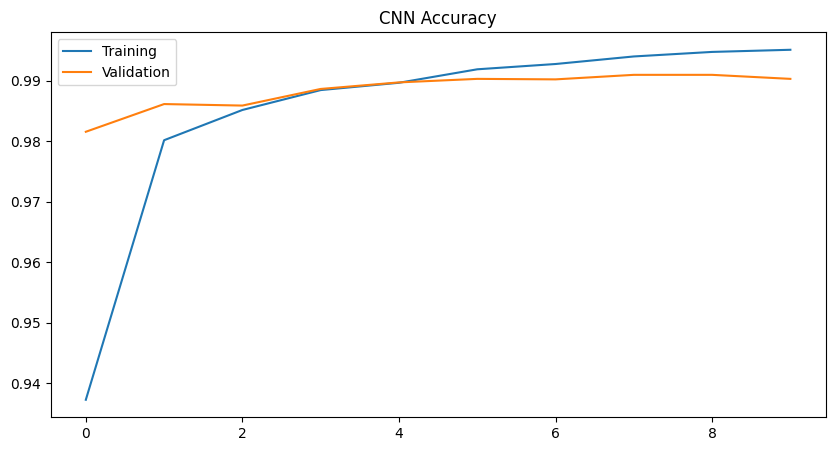

In [14]:
# ============================================================
# ACCURACY CURVE
# ============================================================

plt.figure(
    figsize=(10,5)
)

plt.plot(
    history.history["accuracy"],
    label="Training"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation"
)

plt.legend()

plt.title(
    "CNN Accuracy"
)

plt.show()

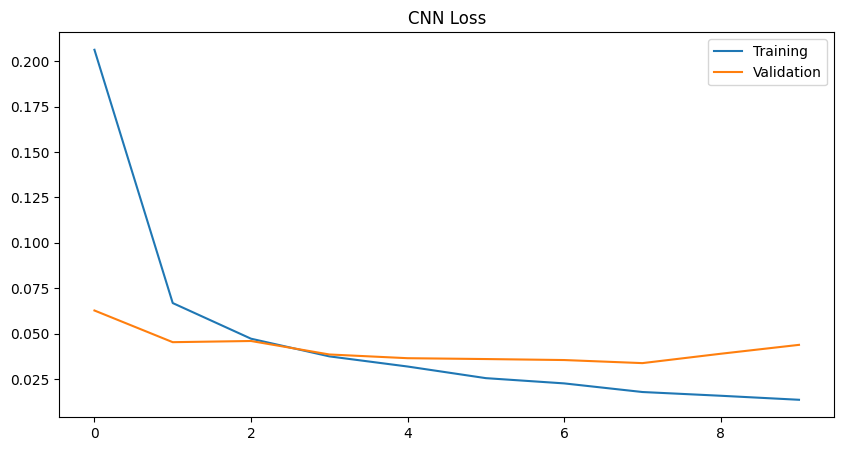

In [15]:
# ============================================================
# LOSS CURVE
# ============================================================

plt.figure(
    figsize=(10,5)
)

plt.plot(
    history.history["loss"],
    label="Training"
)

plt.plot(
    history.history["val_loss"],
    label="Validation"
)

plt.legend()

plt.title(
    "CNN Loss"
)

plt.show()

In [16]:
# ============================================================
# MODEL EVALUATION
# ============================================================

loss, accuracy = model.evaluate(

    X_test,

    y_test_cat

)

print("Accuracy")

print(accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9911 - loss: 0.0294
Accuracy
0.991100013256073


In [17]:
# ============================================================
# PREDICTIONS
# ============================================================

predictions = model.predict(
    X_test
)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

print(
    predicted_classes[:10]
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
[7 2 1 0 4 1 4 9 5 9]


In [18]:
# ============================================================
# ACTUAL VS PREDICTED
# ============================================================

comparison = pd.DataFrame({

    "Actual":
    y_test[:20],

    "Predicted":
    predicted_classes[:20]

})

print(comparison)

    Actual  Predicted
0        7          7
1        2          2
2        1          1
3        0          0
4        4          4
5        1          1
6        4          4
7        9          9
8        5          5
9        9          9
10       0          0
11       6          6
12       9          9
13       0          0
14       1          1
15       5          5
16       9          9
17       7          7
18       3          3
19       4          4


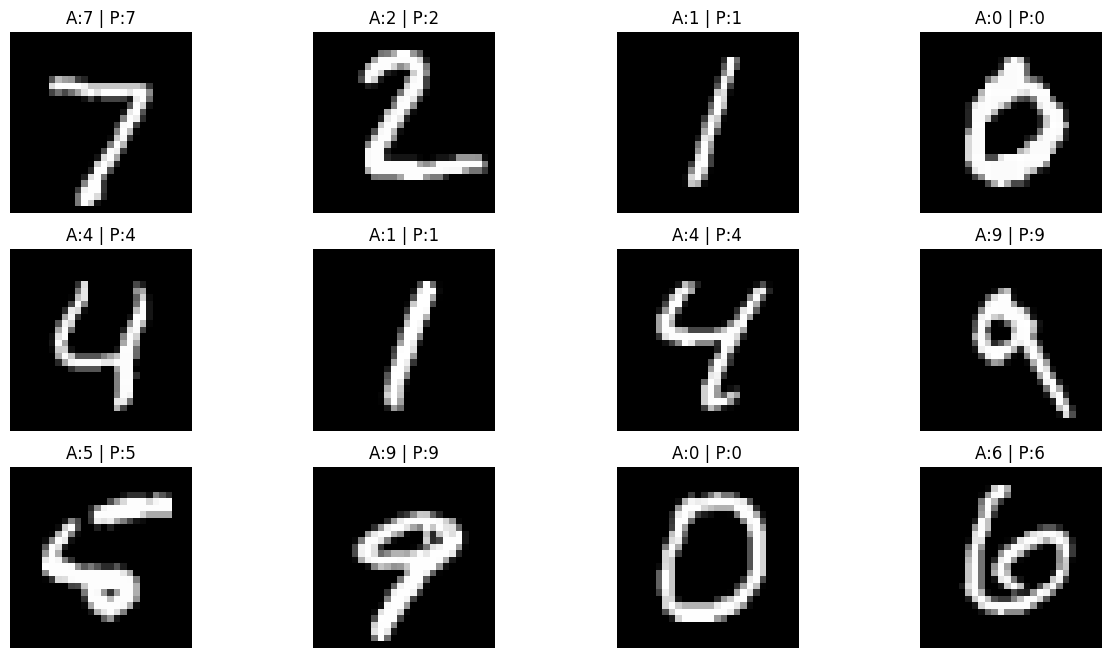

In [19]:
# VISUALIZE PREDICTIONS
# ============================================================

plt.figure(
    figsize=(15,8)
)

for i in range(12):

    plt.subplot(
        3,
        4,
        i+1
    )

    plt.imshow(
        X_test[i].reshape(
            28,
            28
        ),
        cmap="gray"
    )

    plt.title(

        f"A:{y_test[i]} | P:{predicted_classes[i]}"

    )

    plt.axis("off")

plt.show()